In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.simplefilter("ignore")


## Dataset Initialization

In [2]:
result_df = pd.read_csv('formula-1-world-championship-1950-2020/results.csv')
stats_df = pd.read_csv('formula-1-world-championship-1950-2020/status.csv')
drivers_df = pd.read_csv('formula-1-world-championship-1950-2020/drivers.csv')
races_df = pd.read_csv('formula-1-world-championship-1950-2020/races.csv')
constructor_df = pd.read_csv('formula-1-world-championship-1950-2020/constructors.csv')
constructor_standings_df = pd.read_csv('formula-1-world-championship-1950-2020/constructor_standings.csv')
driver_standings_df = pd.read_csv('formula-1-world-championship-1950-2020/driver_standings.csv')
pit_stops_df = pd.read_csv('formula-1-world-championship-1950-2020/pit_stops.csv')

## Dataset Information

In [3]:
datasets = {
    "Results": result_df,
    "Races": races_df,
    "Drivers": drivers_df,
    "Constructors": constructor_df,
    "Pit Stops": pit_stops_df,
    "Driver Standings": driver_standings_df,
    "Constructor Standings": constructor_standings_df,
    "Status": stats_df
}

for name, df in datasets.items():
    print("\n" + "="*70)
    print(f"DATASET: {name}")
    print("="*70)
    df.info()


DATASET: Results
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26759 non-null  object 
 5   grid             26759 non-null  int64  
 6   position         26759 non-null  object 
 7   positionText     26759 non-null  object 
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             26759 non-null  object 
 12  milliseconds     26759 non-null  object 
 13  fastestLap       26759 non-null  object 
 14  rank             26759 non-null  object 
 15  fastestLapTime   26759 non-null  object 
 16  fastestLapSpeed  26759 non-null  object 

# Feature Engineering

## Merge datasets

In [4]:
races_df = races_df[['raceId', 'year', 'round', 'circuitId', 'date']]
races_df['raceId'] = races_df['raceId'].astype(int)


In [5]:
df = (
    result_df
    .merge(races_df, on='raceId')
    .merge(drivers_df, on='driverId')
    .merge(constructor_df, on='constructorId')
    .merge(stats_df, on='statusId')
)
df.head()

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,forename,surname,dob,nationality_x,url_x,constructorRef,name,nationality_y,url_y,status
0,1,18,1,1,22,1,1,1,1,10.0,...,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished
1,2,18,2,2,3,5,2,2,2,8.0,...,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,Finished
2,3,18,3,3,7,7,3,3,3,6.0,...,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,Finished
3,4,18,4,4,5,11,4,4,4,5.0,...,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,Finished
4,5,18,5,1,23,3,5,5,5,4.0,...,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished


### Feature Datatype Change

In [6]:
df['grid'] = pd.to_numeric(df['grid'], errors='coerce')
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
print(df['grid'].dtype)
print(df['dob'].dtype)
print(df['date'].dtype)

int64
datetime64[ns]
datetime64[ns]


### Shifting columns for data leakage

In [7]:
df = df.sort_values(['driverId', 'year', 'raceId'])
df['points_per_season'] = df.groupby(['driverId', 'year'])['points'].cumsum().shift().fillna(0)
df = df.reset_index(drop=True)
df.head(10)

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,surname,dob,nationality_x,url_x,constructorRef,name,nationality_y,url_y,status,points_per_season
0,371,36,1,1,2,4,3,3,3,6.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,0.0
1,392,37,1,1,2,4,2,2,2,8.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,6.0
2,414,38,1,1,2,2,2,2,2,8.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,14.0
3,436,39,1,1,2,4,2,2,2,8.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,22.0
4,458,40,1,1,2,2,2,2,2,8.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,30.0
5,479,41,1,1,2,1,1,1,1,10.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,38.0
6,501,42,1,1,2,1,1,1,1,10.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,48.0
7,525,43,1,1,2,2,3,3,3,6.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,58.0
8,547,44,1,1,2,1,3,3,3,6.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,64.0
9,575,45,1,1,2,10,9,9,9,0.0,...,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,70.0


In [8]:
df = df.sort_values(['driverId', 'raceId'])
df['overall_placement'] = df.groupby('driverId')['positionOrder'].shift().fillna(0)
df = df.reset_index(drop=True)
df.head(10)

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,dob,nationality_x,url_x,constructorRef,name,nationality_y,url_y,status,points_per_season,overall_placement
0,7573,1,1,1,1,18,\N,D,20,0.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Disqualified,98.0,0.0
1,7580,2,1,1,1,12,7,7,7,1.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,0.0,20.0
2,7599,3,1,1,1,9,6,6,6,3.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,1.0,7.0
3,7617,4,1,1,1,5,4,4,4,5.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,4.0,6.0
4,7642,5,1,1,1,14,9,9,9,0.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,9.0,4.0
5,7665,6,1,1,1,19,12,12,12,0.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,9.0,9.0
6,7686,7,1,1,1,16,13,13,13,0.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,9.0,12.0
7,7709,8,1,1,1,18,16,16,16,0.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,9.0,13.0
8,7731,9,1,1,1,5,18,18,18,0.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,+1 Lap,9.0,16.0
9,7734,10,1,1,1,4,1,1,1,10.0,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,Finished,9.0,18.0


### Check Null Values

In [9]:
df.isna().sum()

resultId             0
raceId               0
driverId             0
constructorId        0
number_x             0
grid                 0
position             0
positionText         0
positionOrder        0
points               0
laps                 0
time                 0
milliseconds         0
fastestLap           0
rank                 0
fastestLapTime       0
fastestLapSpeed      0
statusId             0
year                 0
round                0
circuitId            0
date                 0
driverRef            0
number_y             0
code                 0
forename             0
surname              0
dob                  0
nationality_x        0
url_x                0
constructorRef       0
name                 0
nationality_y        0
url_y                0
status               0
points_per_season    0
overall_placement    0
dtype: int64

### New Feature Driver Name (Combination of 2 Features)

In [10]:
df['driver_age'] = (df['date'] - df['dob']).dt.days / 365.25
df['driver_name'] = df['forename']+' '+df['surname']
df[['date','driver_name','driver_age']].tail(20)

,date,driver_name,driver_age
26739,2023-10-08,Liam Lawson,21.653662
26740,2024-10-20,Liam Lawson,22.688569
26741,2024-10-27,Liam Lawson,22.707734
26742,2024-11-03,Liam Lawson,22.726899
26743,2024-11-23,Liam Lawson,22.781656
26744,2024-12-01,Liam Lawson,22.803559
26745,2024-12-08,Liam Lawson,22.822724
26746,2024-03-09,Oliver Bearman,18.836413
26747,2024-09-15,Oliver Bearman,19.356605
26748,2024-11-03,Oliver Bearman,19.490760


In [11]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
resultId,26759.0,13380.977391,1.0,6690.5,13380.0,20069.5,26764.0,7726.134642
raceId,26759.0,551.687283,1.0,300.0,531.0,811.0,1144.0,313.265036
driverId,26759.0,278.67353,1.0,57.0,172.0,399.5,862.0,282.703039
constructorId,26759.0,50.180537,1.0,6.0,25.0,63.0,215.0,61.551498
grid,26759.0,11.134796,0.0,5.0,11.0,17.0,34.0,7.20286
positionOrder,26759.0,12.794051,1.0,6.0,12.0,18.0,39.0,7.665951
points,26759.0,1.987632,0.0,0.0,0.0,2.0,50.0,4.351209
laps,26759.0,46.301768,0.0,23.0,53.0,66.0,200.0,29.496557
statusId,26759.0,17.224971,1.0,1.0,10.0,14.0,141.0,26.026104
year,26759.0,1991.394372,1950.0,1977.0,1991.0,2009.0,2024.0,19.952885


## Clean up unused columns

In [12]:
columns_to_drop = [
    'url_y','url_x','position_x','fastestLapTime','positionText_x','time','driverRef',
    'constructorRef','nationality_y','positionText_y', 'number_y', 'nationality_x', 'points_x', 'statusId', 'code', 'number_x'
]


df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

## Shrink the Dataset to the latest rules

In [13]:
df = df[df['raceId'] > 840]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5980 entries, 71 to 26758
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   resultId           5980 non-null   int64         
 1   raceId             5980 non-null   int64         
 2   driverId           5980 non-null   int64         
 3   constructorId      5980 non-null   int64         
 4   grid               5980 non-null   int64         
 5   position           5980 non-null   object        
 6   positionText       5980 non-null   object        
 7   positionOrder      5980 non-null   int64         
 8   points             5980 non-null   float64       
 9   laps               5980 non-null   int64         
 10  milliseconds       5980 non-null   object        
 11  fastestLap         5980 non-null   object        
 12  rank               5980 non-null   object        
 13  fastestLapSpeed    5980 non-null   object        
 14  year       

### Average Pit stop duration

In [14]:
pit_agg = pit_stops_df.groupby(['raceId','driverId']).agg(
    num_pitstops=('stop','count'),
    avg_pit_duration=('milliseconds','mean'),
    min_pit_duration=('milliseconds','min')
).reset_index()
df = df.merge(pit_agg, on=['raceId','driverId'], how='left')

## Make the Binary classfication for Podium

In [15]:
def podium_helper(pos):
    if pos == 1 or pos == 2 or pos == 3:
        return 1
    else:
        return 0

df['podium'] = df['positionOrder'].apply(podium_helper)
df.head()

,resultId,raceId,driverId,constructorId,grid,position,positionText,positionOrder,points,laps,...,name,status,points_per_season,overall_placement,driver_age,driver_name,num_pitstops,avg_pit_duration,min_pit_duration,podium
0,20780,841,1,1,2,2,2,2,18.0,58,...,McLaren,Finished,240.0,2.0,26.214921,Lewis Hamilton,2.0,23213.000000,23199.0,1
1,20808,842,1,1,2,8,8,8,4.0,56,...,McLaren,Finished,18.0,2.0,26.253251,Lewis Hamilton,4.0,23252.750000,22466.0,0
2,20825,843,1,1,3,1,1,1,25.0,56,...,McLaren,Finished,22.0,8.0,26.272416,Lewis Hamilton,3.0,20659.333333,20533.0,1
3,20852,844,1,1,4,4,4,4,12.0,58,...,McLaren,Finished,47.0,1.0,26.329911,Lewis Hamilton,4.0,24909.250000,20833.0,0
4,20874,845,1,1,3,2,2,2,18.0,66,...,McLaren,Finished,59.0,4.0,26.368241,Lewis Hamilton,4.0,20364.250000,19761.0,1


### New feature Idea for counting number of times lapped in a season

In [16]:
def status_helper(row):
    if row['status'] == 'Finished':
        return 'Finished'
    elif 'Lap' in row['status']:
        return 'Lapped'
    else:
        return 'DNF'

df['status_simp'] = df.apply(status_helper, axis= 1)
df = df.drop('status',  axis=1)
df.head()

,resultId,raceId,driverId,constructorId,grid,position,positionText,positionOrder,points,laps,...,name,points_per_season,overall_placement,driver_age,driver_name,num_pitstops,avg_pit_duration,min_pit_duration,podium,status_simp
0,20780,841,1,1,2,2,2,2,18.0,58,...,McLaren,240.0,2.0,26.214921,Lewis Hamilton,2.0,23213.000000,23199.0,1,Finished
1,20808,842,1,1,2,8,8,8,4.0,56,...,McLaren,18.0,2.0,26.253251,Lewis Hamilton,4.0,23252.750000,22466.0,0,Finished
2,20825,843,1,1,3,1,1,1,25.0,56,...,McLaren,22.0,8.0,26.272416,Lewis Hamilton,3.0,20659.333333,20533.0,1,Finished
3,20852,844,1,1,4,4,4,4,12.0,58,...,McLaren,47.0,1.0,26.329911,Lewis Hamilton,4.0,24909.250000,20833.0,0,Finished
4,20874,845,1,1,3,2,2,2,18.0,66,...,McLaren,59.0,4.0,26.368241,Lewis Hamilton,4.0,20364.250000,19761.0,1,Finished


## Relationship and Grids

In [17]:
df[["grid", "podium"]].groupby(['grid'], as_index=False).mean().sort_values(by='podium', ascending=False)

,grid,podium
1,1,0.807692
2,2,0.686620
3,3,0.503497
4,4,0.342657
5,5,0.192308
6,6,0.139860
7,7,0.080702
10,10,0.045775
9,9,0.041958
8,8,0.031579


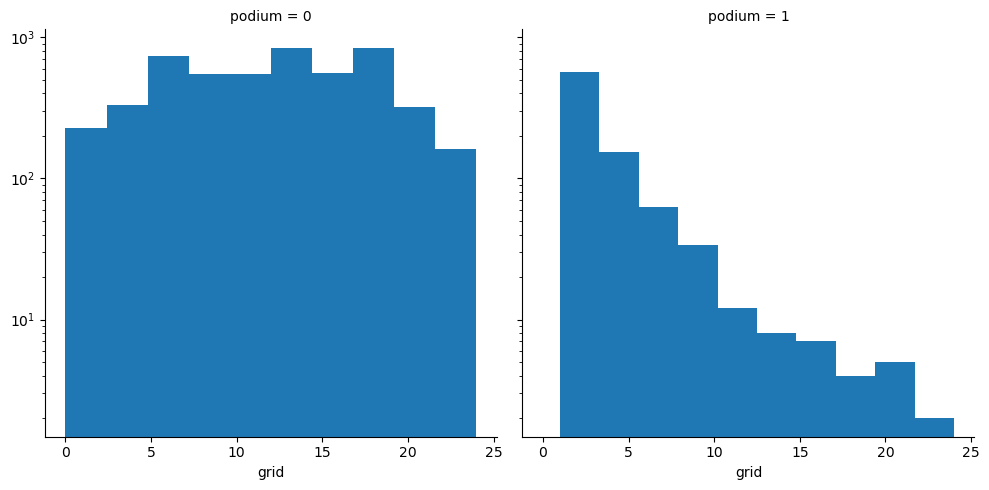

In [18]:
g = sns.FacetGrid(df, col='podium', height=5, aspect=1)
g.map(plt.hist, 'grid', bins=10, log=True)

In [19]:
df[["points_per_season", "podium"]].groupby(['points_per_season'], as_index=False).mean().sort_values(by='podium', ascending=False)

,points_per_season,podium
376,530.0,1.0
375,504.0,1.0
374,479.0,1.0
373,454.0,1.0
372,433.0,1.0
...,...,...
21,21.0,0.0
331,333.0,0.0
336,344.0,0.0
345,356.0,0.0


Vizualizing the pointers before the race and how it relates to making the podium

Trying to get rid of some of the noise being getting rid of the drivers who don't have enough data

In [20]:
min_races = 10
drivers_keep = driver_counts[driver_counts['num_races'] >= min_races]['driverId']
df= df[df['driverId'].isin(drivers_keep)]
df[["driverId", "podium"]].groupby(['driverId'], as_index=False).mean().sort_values(by='podium', ascending=False)

NameError: name 'driver_counts' is not defined

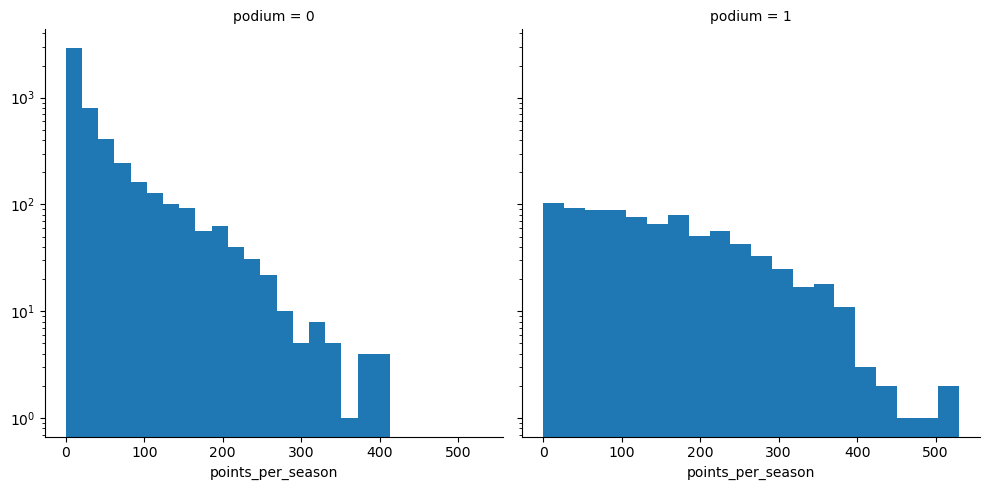

In [21]:
g = sns.FacetGrid(df, col='podium', height=5, aspect=1)
g.map(plt.hist, 'points_per_season', bins=20, log=True)

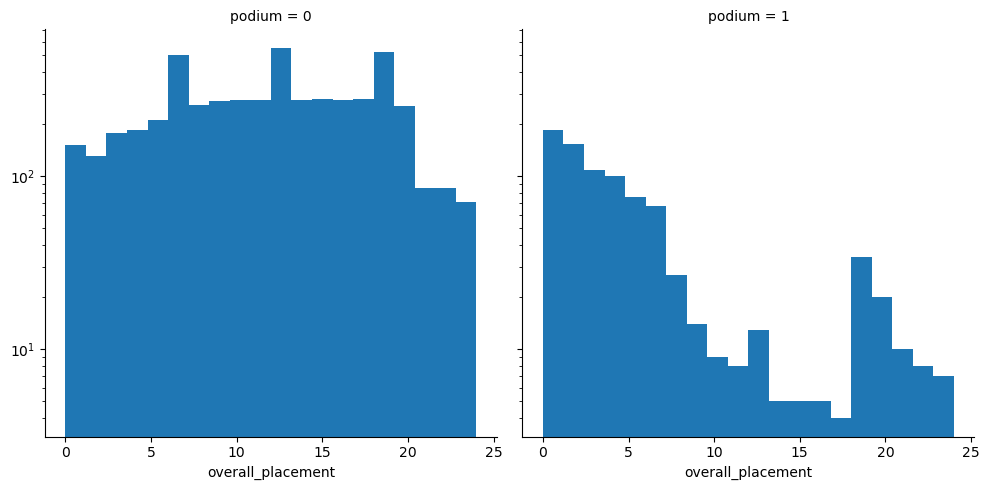

In [22]:
g = sns.FacetGrid(df, col='podium', height=5, aspect=1)
g.map(plt.hist, 'overall_placement', bins=20, log=True)

## Modeling

In [ ]:
assert "year" in df.columns, "df must have a 'year' column"
assert "podium" in df.columns, "df must have a 'podium' target column (0/1)"

df_2011 = df[df["year"] >= 2011].copy()

print("Filtered shape:", df_2011.shape)
print("Years:", df_2011["year"].min(), "to", df_2011["year"].max())
print("Podium rate:", df_2011["podium"].mean())
df_2011.head()

Filtered shape: (5980, 31)
Years: 2011 to 2024
Podium rate: 0.14347826086956522


,resultId,raceId,driverId,constructorId,grid,position,positionText,positionOrder,points,laps,...,name,points_per_season,overall_placement,driver_age,driver_name,num_pitstops,avg_pit_duration,min_pit_duration,podium,status_simp
0,20780,841,1,1,2,2,2,2,18.0,58,...,McLaren,240.0,2.0,26.214921,Lewis Hamilton,2.0,23213.000000,23199.0,1,Finished
1,20808,842,1,1,2,8,8,8,4.0,56,...,McLaren,18.0,2.0,26.253251,Lewis Hamilton,4.0,23252.750000,22466.0,0,Finished
2,20825,843,1,1,3,1,1,1,25.0,56,...,McLaren,22.0,8.0,26.272416,Lewis Hamilton,3.0,20659.333333,20533.0,1,Finished
3,20852,844,1,1,4,4,4,4,12.0,58,...,McLaren,47.0,1.0,26.329911,Lewis Hamilton,4.0,24909.250000,20833.0,0,Finished
4,20874,845,1,1,3,2,2,2,18.0,66,...,McLaren,59.0,4.0,26.368241,Lewis Hamilton,4.0,20364.250000,19761.0,1,Finished


In [35]:
from sklearn.model_selection import train_test_split

target_col = "podium"

drop_cols = [
    "podium",
    "position",
    "positionText",
    "positionOrder",
    "points",
    "rank",
]


# drop_cols.append("points_per_season")  

drop_cols = [c for c in drop_cols if c in df_2011.columns]

X = df_2011.drop(columns=drop_cols)
y = df_2011[target_col].astype(int)

print("Dropped:", drop_cols)
print("X shape:", X.shape, "y mean:", y.mean())


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train podium rate:", y_train.mean(), "Test podium rate:", y_test.mean())

Dropped: ['podium', 'position', 'positionText', 'positionOrder', 'points', 'rank']
X shape: (5980, 25) y mean: 0.14347826086956522
Train: (4784, 25) Test: (1196, 25)
Train podium rate: 0.14339464882943143 Test podium rate: 0.14381270903010032


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop"
)

Numeric cols: 15 Categorical cols: 10


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print("Log Reg")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Log Reg
Accuracy: 0.8904682274247492
Confusion Matrix:
 [[920 104]
 [ 27 145]]
              precision    recall  f1-score   support

           0     0.9715    0.8984    0.9335      1024
           1     0.5823    0.8430    0.6888       172

    accuracy                         0.8905      1196
   macro avg     0.7769    0.8707    0.8112      1196
weighted avg     0.9155    0.8905    0.8983      1196

